In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt # type: ignore
import seaborn as sns   # type: ignore
from sklearn.linear_model import LinearRegression,LogisticRegression  # type: ignore
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,RandomForestClassifier, GradientBoostingClassifier # type: ignore
from sklearn.inspection import permutation_importance # type: ignore
from sklearn.model_selection import train_test_split, KFold, cross_val_score # type: ignore
from sklearn.preprocessing import MinMaxScaler,StandardScaler  #type: ignore
from sklearn.metrics import mean_squared_error,accuracy_score, precision_score, recall_score,confusion_matrix,ConfusionMatrixDisplay # type: ignore
from sklearn.decomposition import PCA    # type: ignore




# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        file= os.path.join(dirname, filename)
        # print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
df=pd.read_csv(file)
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


# Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [4]:
df.duplicated().sum()       # To check for duplicate rows

np.int64(0)

In [5]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


In [6]:
courses = df["course_id"].unique()      # List of distinct course

courses

array(['C_01', 'C_06', 'C_03', 'C_21', 'C_08', 'C_07', 'C_23', 'C_15',
       'C_24', 'C_02', 'C_10', 'C_14', 'C_13', 'C_16', 'C_25', 'C_05',
       'C_20', 'C_09', 'C_19', 'C_22', 'C_04', 'C_18', 'C_17', 'C_11',
       'C_12'], dtype=object)

In [7]:
instructor = df["instructor_id"].unique()       # List of distinct instructors

instructor

array(['I_044', 'I_119', 'I_050', 'I_024', 'I_001', 'I_026', 'I_082',
       'I_009', 'I_114', 'I_038', 'I_007', 'I_064', 'I_105', 'I_084',
       'I_087', 'I_086', 'I_088', 'I_033', 'I_032', 'I_117', 'I_111',
       'I_039', 'I_100', 'I_018', 'I_021', 'I_085', 'I_010', 'I_055',
       'I_112', 'I_113', 'I_047', 'I_090', 'I_107', 'I_052', 'I_065',
       'I_103', 'I_096', 'I_028', 'I_045', 'I_115', 'I_079', 'I_027',
       'I_092', 'I_110', 'I_020', 'I_074', 'I_118', 'I_035', 'I_101',
       'I_109', 'I_097', 'I_019', 'I_040', 'I_029', 'I_075', 'I_036',
       'I_002', 'I_043', 'I_025', 'I_013', 'I_023', 'I_071', 'I_081',
       'I_062', 'I_116', 'I_072', 'I_066', 'I_016', 'I_017', 'I_069',
       'I_057', 'I_060', 'I_098', 'I_034', 'I_014', 'I_058', 'I_046',
       'I_059', 'I_022', 'I_041', 'I_011', 'I_005', 'I_089', 'I_070',
       'I_094', 'I_093', 'I_091', 'I_108', 'I_095', 'I_051', 'I_080',
       'I_063', 'I_102', 'I_012', 'I_106', 'I_068', 'I_048', 'I_003',
       'I_077', 'I_0

In [8]:
batches = df.groupby("instructor_id")["course_id"].nunique()   # List of no of batches taught by instructors 
batches

instructor_id
I_001    16
I_002    10
I_003    14
I_004    10
I_005    13
         ..
I_116    13
I_117    11
I_118    14
I_119    12
I_120     9
Name: course_id, Length: 120, dtype: int64

The data contains info about 25 courses and 120 instructors. It also has unique , non null & non missing values.

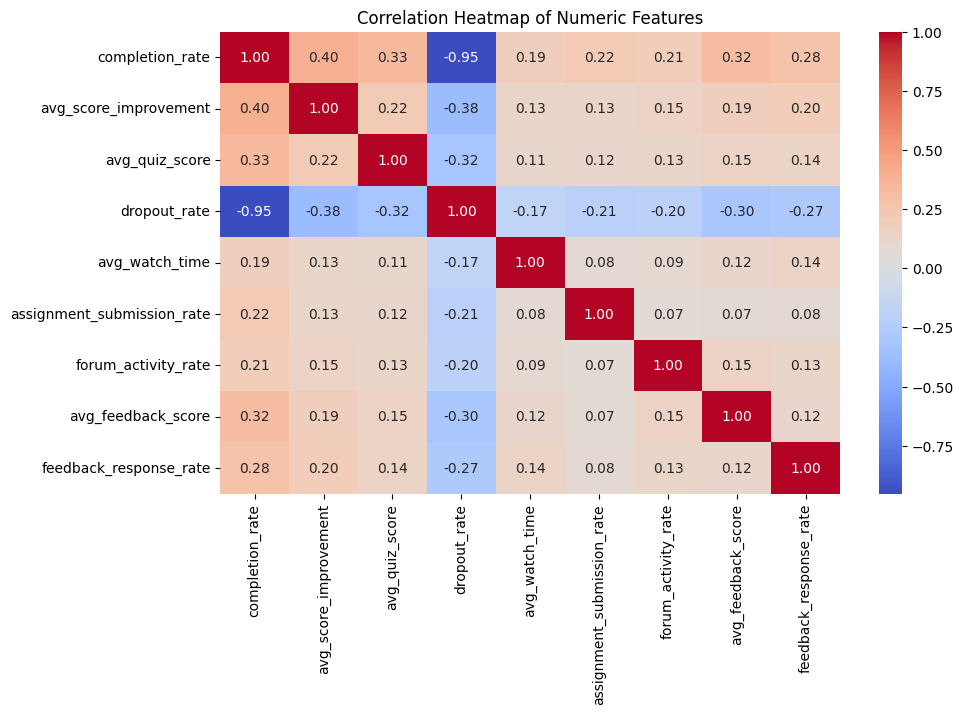

In [9]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

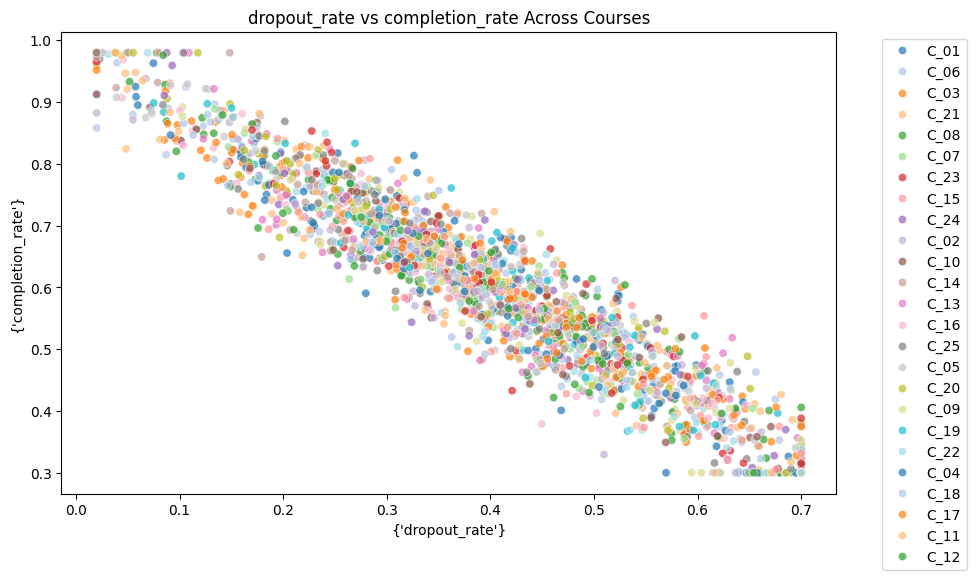

In [10]:
plt.figure(figsize=(10,6))
A='dropout_rate'
B='completion_rate'
sns.scatterplot(
    data=df,x=A, y=B,
    hue="course_id",
    palette="tab20",
    alpha=0.7
)


plt.title(f"{A} vs {B} Across Courses")
plt.xlabel({A})
plt.ylabel({B})

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.show()

Observation : Completion rate and dropout rate are almost perfectly negatively correlated, indicating they represent the same underlying outcome. Metrics related to learning outcomes (score improvement, quiz scores) , engagement metrics and student satisfaction (feedback score) show positive relationships with each other.

# Feature Analysis

## Step 1: Data Preprocessing and Feature Scaling

### Objective:


We need to scale the features to ensure that all features contribute equally to the modeling process. This is crucial because some features have different units (e.g., "avg_feedback_score" ranges from 1 to 5, while "completion_rate" ranges from 0 to 1), and unscaled features might disproportionately affect model performance.

Approach:

Scaling Features:

We will use StandardScaler to scale the numeric features to have a mean of 0 and a standard deviation of 1. This will ensure that each feature is on the same scale, improving model performance and stability.

In [11]:
features = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",    
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

#df["dropout_rate"] = 1 - df["dropout_rate"]

# scaler = MinMaxScaler()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

## Step 2: Calculate Course Quality Score

Objective:

The Course Quality Score should measure how well an instructor is delivering the course, factoring in both linear (via PCA) and non-linear (via Random Forest) aspects of the data.

Mathematical Formulas:

PCA Score: PCA reduces the feature space to a single principal component that explains the maximum variance in the data.

$$
\text{PCA Score} = \text{Principal Component 1 Score}
$$

The score is normalized to a range from 0 to 100.

Random Forest Score: Random Forest regression is used to compute the feature importances, which are normalized to sum up to 1, and then a weighted score is computed.

$$
\text{RF Score} = \sum_{i=1}^{n} \text{Feature Weight}_i \times \text{Feature Value}_i
$$

Each feature is weighted according to its importance in predicting the course quality.

Course Quality Score: We combine the PCA and Random Forest scores with the following formula:

$$
\text{Course Quality Score} = 0.4 \times \text{PCA Score} + 0.4 \times \text{RF Score} + 0.2 \times \text{LR Score}
$$

Where:
- PCA Score is the score derived from Principal Component Analysis, capturing the maximum variance in the features.
- RF Score is the score obtained from a Random Forest model that uses feature importance to weight the contribution of each feature.


The linear regression score (LR) can be included as an additional model for comparison.

In [12]:
pca = PCA(n_components=1)
pca_score = pca.fit_transform(X_scaled)

df["pca_score"] = pca_score.flatten()


df["pca_score"] = (
    (df["pca_score"] - df["pca_score"].min()) /
    (df["pca_score"].max() - df["pca_score"].min())
) * 100


lr = LinearRegression()
lr.fit(X_scaled, df["pca_score"])

df["lr_score"] = lr.predict(X_scaled)

df["lr_score"] = (
    (df["lr_score"] - df["lr_score"].min()) /
    (df["lr_score"].max() - df["lr_score"].min())
) * 100


rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_scaled, df["pca_score"])

importances = rf.feature_importances_
weights = importances / importances.sum()

rf_score = np.dot(X_scaled, weights)

df["rf_score"] = (
    (rf_score - rf_score.min()) /
    (rf_score.max() - rf_score.min())
) * 100

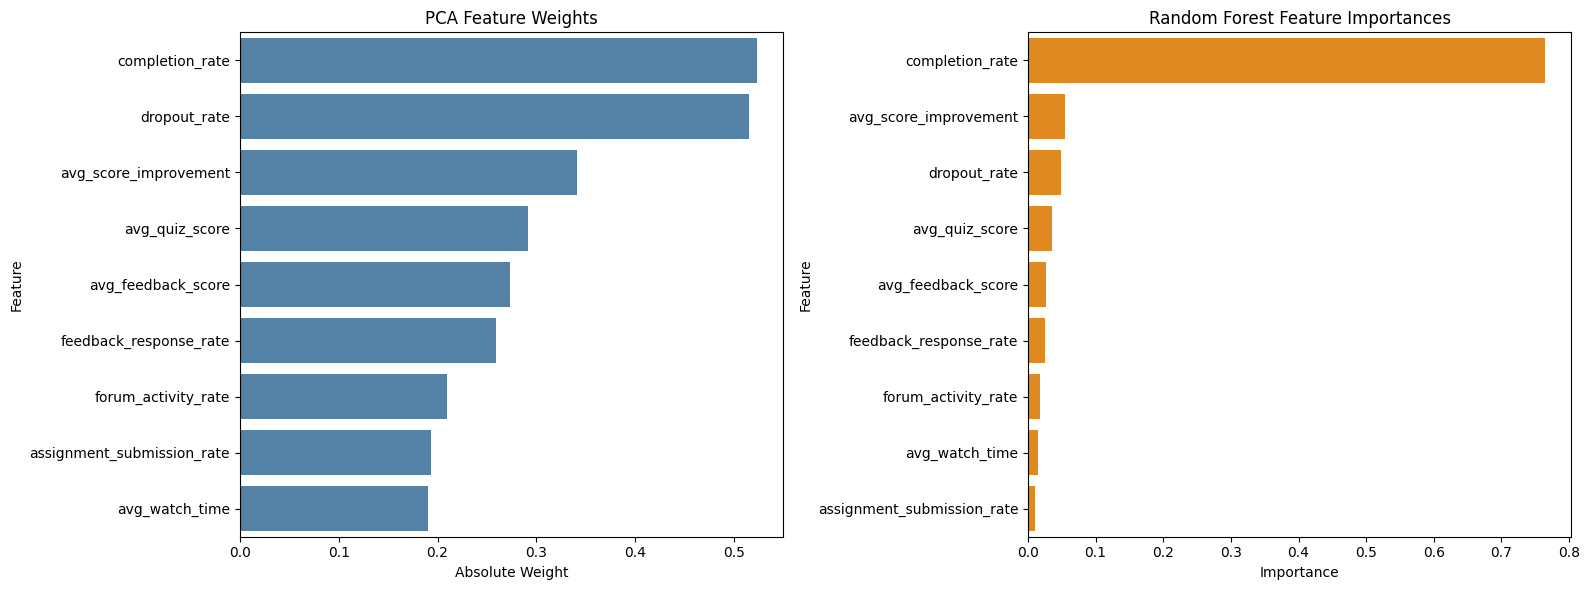

In [13]:
# PCA component weights
pca_weights = pd.DataFrame({
    "feature": features,
    "pca_weight": np.abs(pca.components_[0])
}).sort_values("pca_weight", ascending=False)

# Random forest feature importances
rf_weights = pd.DataFrame({
    "feature": features,
    "rf_weight": rf.feature_importances_
}).sort_values("rf_weight", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=pca_weights,
    x="pca_weight",
    y="feature",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("PCA Feature Weights")
axes[0].set_xlabel("Absolute Weight")
axes[0].set_ylabel("Feature")

sns.barplot(
    data=rf_weights,
    x="rf_weight",
    y="feature",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Random Forest Feature Importances")
axes[1].set_xlabel("Importance")
axes[1].set_ylabel("Feature")

plt.tight_layout()
plt.show()

PCA Feature Weights:

The first graph shows the feature weights from a Principal Component Analysis (PCA) model. It highlights which features contribute most to the first principal component.

Most important features: The features that contribute the most are completion_rate, followed by dropout_rate and avg_score_improvement. These features have higher weights, suggesting they play a larger role in explaining the variance in the data.

Least important feature: avg_watch_time seems to have a relatively smaller weight, suggesting it contributes less to the PCA model.

Random Forest Feature Importances: The second graph shows the feature importances from a Random Forest model.

Most important features: completion_rate is the most important feature, followed by avg_score_improvement and dropout_rate. This suggests that Random Forest has identified similar important features as PCA, with a strong emphasis on completion rate.

Least important feature: assignment_submission_rate is ranked the least important, similar to the PCA results, though the importance is still significant compared to avg_watch_time in PCA.

In [14]:
df["course_quality_score"] = (
    0.3 * df["pca_score"] +
    0.5 * df["rf_score"] 
    + 0.2 * df["lr_score"]
)
df

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,pca_score,lr_score,rf_score,course_quality_score
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193,17.856476,17.856476,4.857606,11.357041
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087,54.448355,54.448355,53.879348,54.163852
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433,24.372078,24.372078,7.485079,15.928579
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000,61.698113,61.698113,53.151471,57.424792
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710,56.723098,56.723098,41.906429,49.314763
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,B_1131,I_047,C_17,0.589309,19.227979,46.242023,0.433437,0.848756,0.641781,0.261656,4.339478,0.643116,36.257632,36.257632,40.363861,38.310747
1996,B_1295,I_037,C_25,0.980000,36.737265,93.249093,0.103561,1.000000,0.688175,0.375195,4.912936,0.959988,93.036079,93.036079,98.679481,95.857780
1997,B_0861,I_033,C_06,0.531447,24.907878,83.990693,0.512266,0.918924,0.598276,0.271701,4.211113,0.773437,46.799242,46.799242,38.971341,42.885292
1998,B_1460,I_069,C_10,0.641025,22.395362,80.044231,0.317231,0.558183,0.575629,0.135500,4.182141,0.962627,49.067881,49.067881,49.398580,49.233230


Observations:
The course quality score combines PCA and Random Forest to capture both linear and non-linear factors.

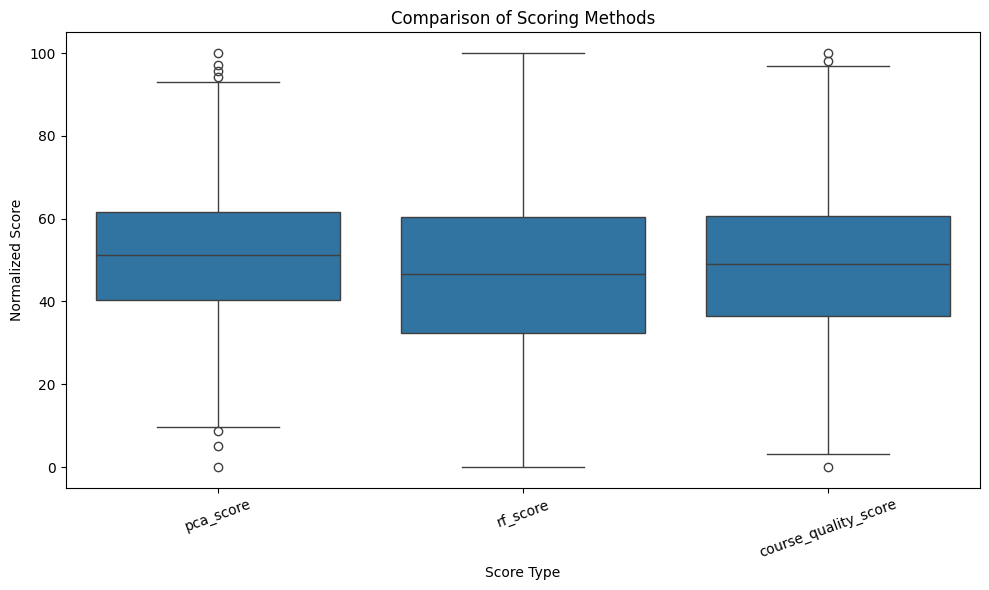

In [15]:
score  = df[["pca_score","rf_score", "course_quality_score"]].copy()  # "lr_score",

score_long = score.melt(
    var_name="score_type",
    value_name="score_value"
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=score_long, x="score_type", y="score_value")
plt.title("Comparison of Scoring Methods")
plt.xlabel("Score Type")
plt.ylabel("Normalized Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Key observations:

Central tendency (median):

All three scores have similar medians, roughly around 45–50.
pca_score appears slightly higher than rf_score, while course_quality_score is close to PCA.

Spread (variability):

rf_score shows the widest spread (largest variability), with values ranging from near 0 to 100.
pca_score and course_quality_score have slightly tighter distributions but still show broad ranges.

Outliers:

pca_score and course_quality_score have several high-end outliers (near 95–100).
pca_score also has some low-end outliers (close to 0–10).
rf_score appears to have fewer extreme outliers but a wide overall range.

Range:

All methods span a similar overall range (approximately 0 to 100), indicating consistent normalization.

Overall interpretation:

The three scoring methods produce comparable central values, but differ in how spread out their scores are.
rf_score is more variable, while pca_score and course_quality_score are slightly more consistent but still show notable extremes.

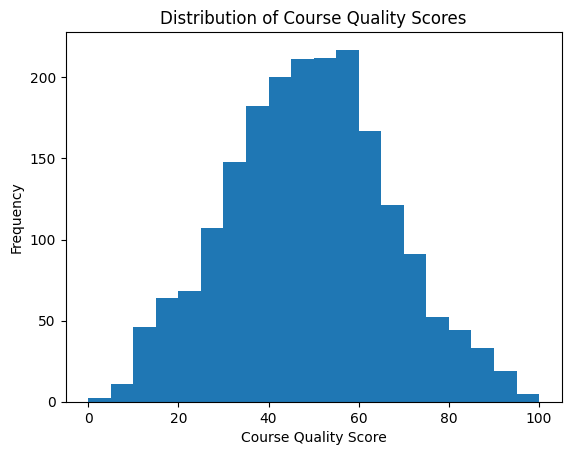

In [16]:
plt.figure()

plt.hist(df["course_quality_score"], bins=20)
plt.xlabel("Course Quality Score")
plt.ylabel("Frequency")
plt.title("Distribution of Course Quality Scores")

plt.show()

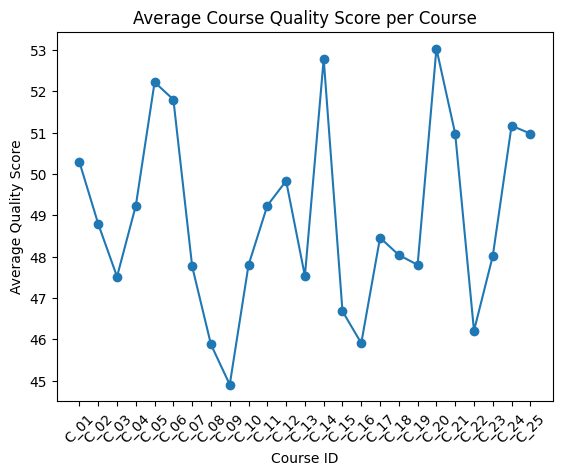

In [17]:
course_avg = df.groupby("course_id")["course_quality_score"].mean()

plt.figure()

plt.plot(course_avg.index, course_avg.values, marker='o')
plt.xticks(rotation=45)

plt.xlabel("Course ID")
plt.ylabel("Average Quality Score")
plt.title("Average Course Quality Score per Course")

plt.show()

# Instructor Effectiveness Score

Objective

The objective of this analysis is to:

Derive a course difficulty score using learner performance metrics

Analyze course quality trends across courses

Compute an instructor score that accounts for:

Course difficulty

Course quality

Instructor experience

Methodology

1. Course-Level Aggregation

We compute average metrics per course:

Completion Rate

$$
\text{Completion Rate}_c = \frac{1}{N_c} \sum_{i=1}^{N_c} \text{completion}_i
$$

Quiz Score

$$
\text{Average Quiz Score}_c = \frac{1}{N_c} \sum_{i=1}^{N_c} \text{score}_i
$$

Score Improvement

$$
\text{Average Improvement}_c = \frac{1}{N_c} \sum_{i=1}^{N_c} \text{improvement}_i
$$


2. Difficulty Feature Engineering

We transform features so that higher values indicate higher difficulty.

$$
\text{inv\_completion} = 1 - \text{Completion Rate}
$$

$$
\text{inv\_score} = 1 - \frac{\text{Average Quiz Score}}{100}
$$

$$
\text{low\_improvement} = 1 - \frac{\text{Average Improvement}}{40}
$$


3. Feature Scaling (Min-Max Normalization)

$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

4. PCA-Based Difficulty Score


We combine features into a single score using PCA.

$$
Z = w_1 x_1 + w_2 x_2 + w_3 x_3
$$

5. Difficulty Score Normalization (0–100)

$$
D' = \frac{D - D_{\min}}{D_{\max} - D_{\min}} \times 100
$$

6. Course Quality Aggregation

$$
Q_c = \frac{1}{N_c} \sum_{i=1}^{N_c} Q_i
$$

7. Instructor Experience (Log Scaling)

$$
\text{Experience} = \log(1 + \text{batches})
$$

8. Difficulty-Weighted Quality Score

$$
\text{Weighted Quality} = \frac{\sum_{i=1}^{n} Q_i \cdot D_i}{\sum_{i=1}^{n} D_i}
$$

9. Final Instructor Score

$$
\text{Instructor Score} = \frac{\sum_{i=1}^{n} Q_i \cdot D_i}{\sum_{i=1}^{n} D_i} + \lambda \cdot \text{Experience}
$$

In [18]:
course_stats = df.groupby("course_id").agg({
    "completion_rate": "mean",
    #"dropout_rate": "mean",
    "avg_score_improvement": "mean",
    "avg_quiz_score": "mean"
}).reset_index()

course_stats["inv_completion"] = 1 - course_stats["completion_rate"]
course_stats["inv_score"] = 1 - (course_stats["avg_quiz_score"] / 100)
course_stats["low_improvement"] = 1 - (course_stats["avg_score_improvement"] / 40)

diff_features = ["inv_completion",  "low_improvement", "inv_score"] #"dropout_rate"

scaler_diff = MinMaxScaler()
X_diff = scaler_diff.fit_transform(course_stats[diff_features])

pca_diff = PCA(n_components=1)
difficulty = pca_diff.fit_transform(X_diff)

course_stats["difficulty_score"] = difficulty
course_stats["difficulty_score"] = (
    (course_stats["difficulty_score"] - course_stats["difficulty_score"].min()) /
    (course_stats["difficulty_score"].max() - course_stats["difficulty_score"].min())
) * 100

df = df.merge(
    course_stats[["course_id", "difficulty_score"]],
    on="course_id",
    how="left"
)

In [19]:
experience = np.log1p(batches)
df["experience_score"] = df["instructor_id"].map(experience)


def compute_instructor_score(group, lambda_exp=0.2):
    Q = group["course_quality_score"]
    D = group["difficulty_score"]

    weighted_quality = np.sum(Q * D) / np.sum(D)
    experience = group["experience_score"].iloc[0]

    return weighted_quality + lambda_exp * experience

In [20]:
corr = df["difficulty_score"].corr(df["course_quality_score"])
print("Correlation:", corr)

Correlation: -0.11641704639141637


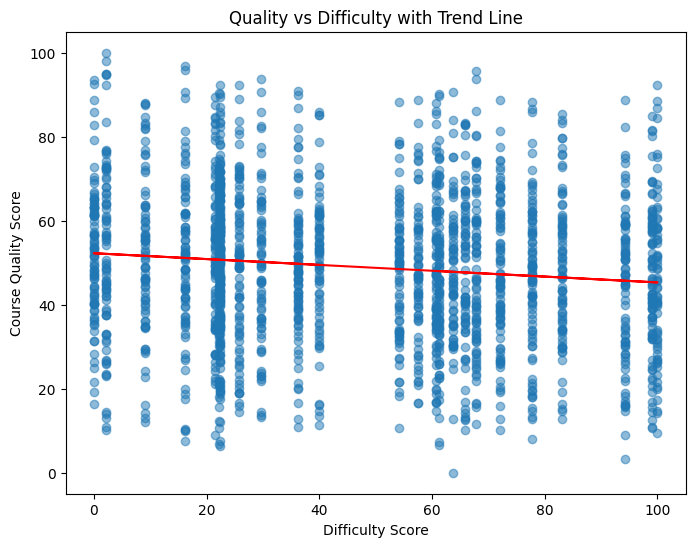

In [21]:
z = np.polyfit(df["difficulty_score"], df["course_quality_score"], 1)
p = np.poly1d(z)

plt.figure(figsize=(8,6))
plt.scatter(df["difficulty_score"], df["course_quality_score"], alpha=0.5)
plt.plot(df["difficulty_score"], p(df["difficulty_score"]), color='red')

plt.xlabel("Difficulty Score")
plt.ylabel("Course Quality Score")
plt.title("Quality vs Difficulty with Trend Line")

plt.show()

Observations

1. Difficulty Interpretation
   
Courses with: Low completion ,Low scores,Low improvement are classified as more difficult

2. Instructor Evaluation

Instructors are rewarded for: High performance in difficult courses , Experience adds a stabilizing factor

3. Quality vs Difficulty Relationship

If correlation < 0 → Higher difficulty leads to lower quality

If correlation > 0 → Difficult courses are still high quality

# ML Model

The objective of this ML pipeline is to quantitatively evaluate and rank instructor effectiveness using behavioral and performance data, and then segment instructors into meaningful tiers (Low/Medium/High) for decision-making. Instead of relying purely on a handcrafted formula, we compute a robust target score that combines course quality, difficulty, and experience, and then train a regression model (Lasso) using only raw features so the system can learn underlying patterns without leakage. Lasso is chosen because it performs well on structured, mostly linear data and automatically removes irrelevant features, making the model both accurate and interpretable. We validate models using cross-validation and RMSE to ensure reliability, then use the predicted scores to assign tiers via KMeans clustering, avoiding arbitrary thresholds. The end goal is a production-ready, data-driven scoring system that not only ranks instructors fairly but also provides actionable insights into what drives effectiveness, enabling better training, evaluation, and strategic decisions.

In [22]:
features_raw = [
    "completion_rate",
    "avg_score_improvement",
    "avg_quiz_score",
    "dropout_rate",
    "avg_watch_time",
    "assignment_submission_rate",
    "forum_activity_rate",
    "avg_feedback_score",
    "feedback_response_rate"
]

instructor_features = (
    df.groupby("instructor_id")[features_raw]
    .mean()
    .reset_index()
)


# Target (your formula)
instructor_target = df.groupby("instructor_id").apply(compute_instructor_score)
instructor_target = instructor_target.reset_index(name="target_score")

instructor_df = instructor_features.merge(
    instructor_target,
    on="instructor_id"
)

/tmp/ipykernel_16/2700486625.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  instructor_target = df.groupby("instructor_id").apply(compute_instructor_score)


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

X = instructor_df[features_raw]
y = instructor_df["target_score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
models = {
    # Linear (needs scaling)
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.1))
    ]),

    # Tree models (NO scaling)
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=42),
    
    "ExtraTrees": ExtraTreesRegressor(n_estimators=300, random_state=42),
    
    "GradientBoosting": GradientBoostingRegressor(),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    
}

In [25]:
results = []

for name, model in models.items():
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    
    results.append({
        "Model": name,
        "RMSE": -scores.mean(),
        "STD": scores.std()
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
print(results_df)

              Model      RMSE       STD
1             Lasso  1.632510  0.262895
0             Ridge  1.689068  0.269736
3        ExtraTrees  2.065674  0.602819
5           XGBoost  2.181095  0.780125
4  GradientBoosting  2.485465  0.604594
2      RandomForest  2.497075  0.746020


In [26]:
from sklearn.metrics import mean_squared_error, r2_score

best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Model:", best_model_name)
print("Test RMSE:", rmse)
print("R2 Score:", r2)

Best Model: Lasso
Test RMSE: 2.0916354216414286
R2 Score: 0.9821484444225645


In [27]:
from sklearn.cluster import KMeans

# Predict for all
instructor_df["pred_score"] = best_model.predict(X)

kmeans = KMeans(n_clusters=3, random_state=42)
instructor_df["cluster"] = kmeans.fit_predict(
    instructor_df[["pred_score"]]
)

# Order clusters
cluster_means = instructor_df.groupby("cluster")["pred_score"].mean()
ordered = cluster_means.sort_values().index

tier_map = {
    ordered[0]: "Low",
    ordered[1]: "Medium",
    ordered[2]: "High"
}

instructor_df["tier"] = instructor_df["cluster"].map(tier_map)

instructor_df

,instructor_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,target_score,pred_score,cluster,tier
0,I_001,0.543887,26.641462,78.900194,0.470593,0.766513,0.726893,0.240551,4.217743,0.694858,44.028211,43.400310,2,Medium
1,I_002,0.730874,30.166242,81.737198,0.247194,0.837393,0.774394,0.289610,4.343002,0.784338,67.284483,64.293324,1,High
2,I_003,0.768447,29.977813,81.590928,0.234828,0.818441,0.779606,0.296224,4.450034,0.812132,64.172038,67.841671,1,High
3,I_004,0.458328,22.912021,77.680317,0.547261,0.793130,0.758317,0.226259,4.076410,0.721460,34.797336,33.654408,0,Low
4,I_005,0.859747,32.588652,85.828159,0.145733,0.847026,0.876942,0.333519,4.202516,0.784197,78.419908,77.443786,1,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,I_116,0.597106,26.029714,78.640236,0.412782,0.761489,0.660695,0.274891,4.091469,0.719787,47.710321,47.164982,2,Medium
116,I_117,0.691715,28.430884,80.981607,0.312481,0.793272,0.814243,0.265179,4.305839,0.713759,59.490450,58.750964,2,Medium
117,I_118,0.820753,32.636791,87.071798,0.202034,0.773422,0.829285,0.258419,4.641986,0.868611,77.022888,75.409919,1,High
118,I_119,0.600597,25.159349,80.735733,0.399761,0.774830,0.766803,0.227028,4.315403,0.759761,47.397322,48.874885,2,Medium


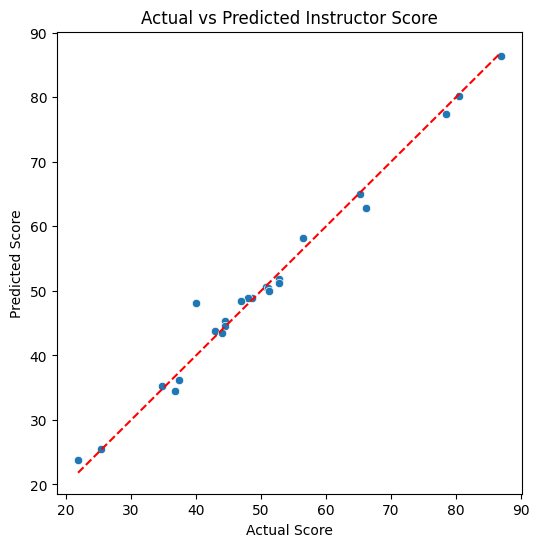

In [28]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Instructor Score")

plt.show()

Insights :

Points close to diagonal → good model

Spread → prediction errors

Systematic shift → bias

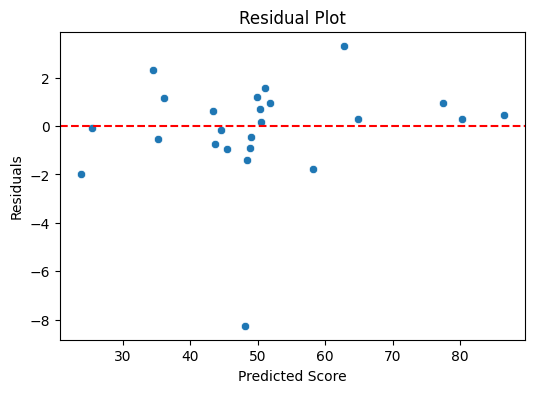

In [29]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Score")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

Insight:

Random scatter → good

Pattern/curve → model missing something

Funnel shape → heteroscedasticity

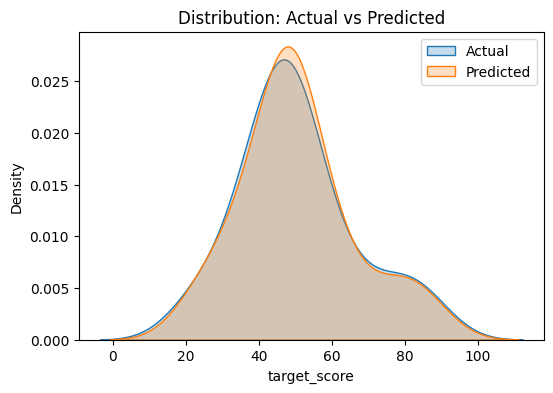

In [30]:
plt.figure(figsize=(6,4))
sns.kdeplot(y_test, label="Actual", fill=True)
sns.kdeplot(y_pred, label="Predicted", fill=True)

plt.legend()
plt.title("Distribution: Actual vs Predicted")

plt.show()

Insights:
Overlap = good

Shift = bias

Narrower predicted = underfitting

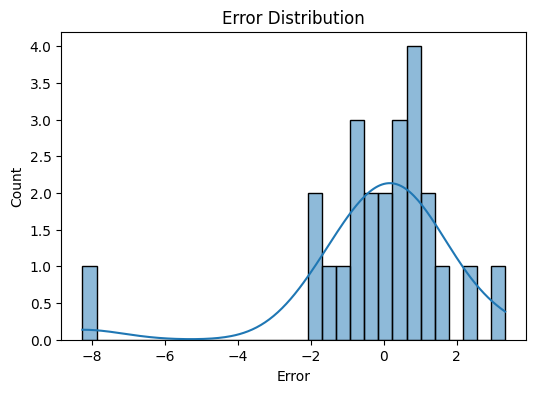

In [31]:
errors = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(errors, bins=30, kde=True)

plt.title("Error Distribution")
plt.xlabel("Error")

plt.show()

Insight :

Centered at 0 → good

Skewed → bias

Wide → unstable model

In [32]:
tier_counts = instructor_df['tier'].value_counts().sort_index()
tier_pct = (tier_counts / tier_counts.sum() * 100).round(2)

class_balance_df = pd.DataFrame({
    'count': tier_counts,
    'percentage': tier_pct
})

print(class_balance_df)

imbalance_gap = float(tier_pct.max() - tier_pct.min())
if imbalance_gap > 15:
    print(f"\nClass imbalance note: noticeable imbalance detected (max-min = {imbalance_gap:.2f}%).")
else:
    print(f"\nClass imbalance note: class distribution is reasonably balanced (max-min = {imbalance_gap:.2f}%).")

        count  percentage
tier                     
High       25       20.83
Low        32       26.67
Medium     63       52.50

Class imbalance note: noticeable imbalance detected (max-min = 31.67%).


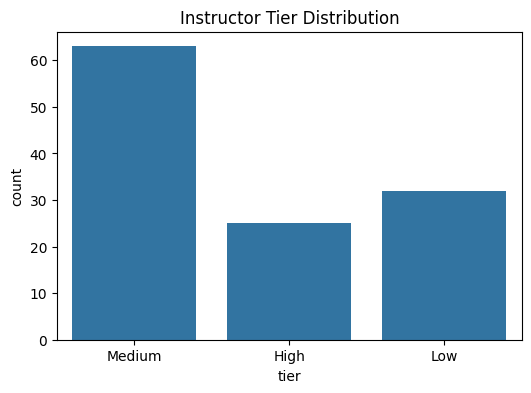

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(x=instructor_df["tier"])

plt.title("Instructor Tier Distribution")
plt.show()

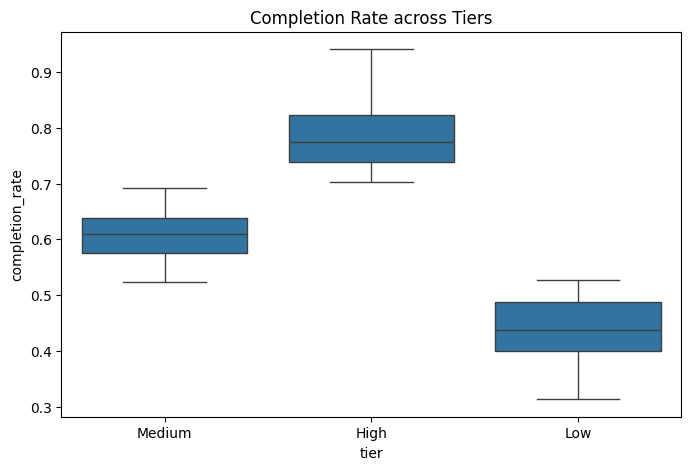

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x=instructor_df["tier"],
    y=instructor_df["completion_rate"]
)

plt.title("Completion Rate across Tiers")
plt.show()

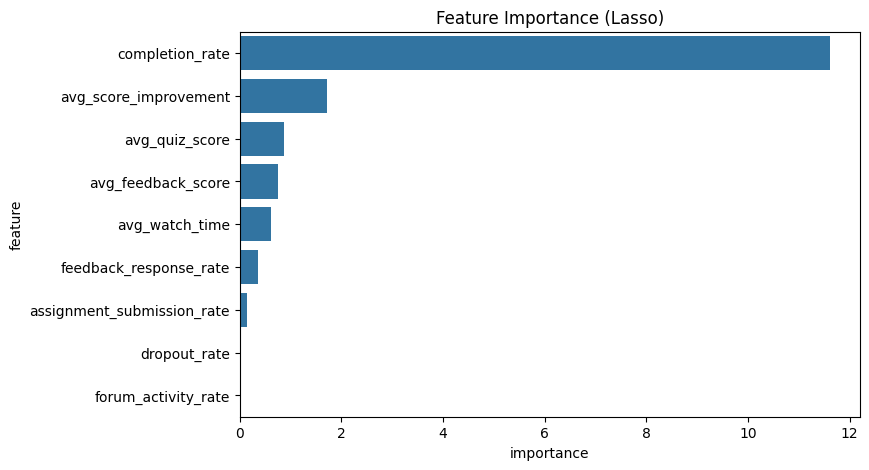

In [35]:
lasso = best_model.named_steps["model"]

coeffs = pd.DataFrame({
    "feature": X.columns,
    "importance": lasso.coef_
}).sort_values("importance", key=abs, ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="importance", y="feature", data=coeffs)

plt.title("Feature Importance (Lasso)")
plt.show()

# Result

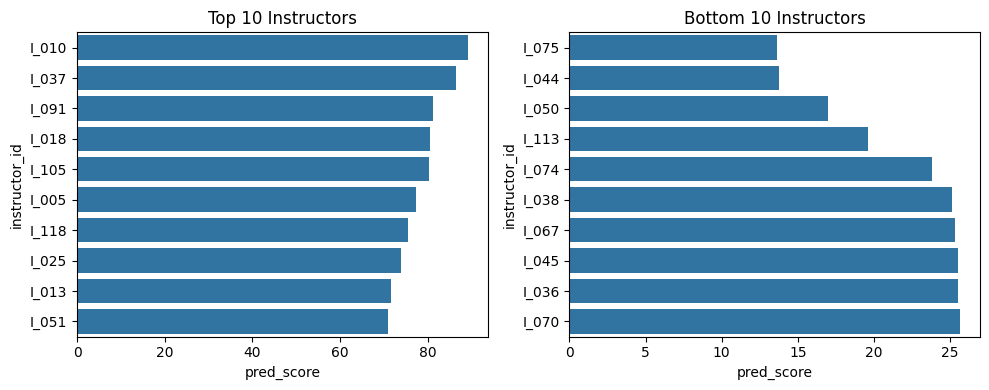

In [36]:
temp = instructor_df.copy()

top10 = temp.sort_values("pred_score", ascending=False).head(10)
bottom10 = temp.sort_values("pred_score").head(10)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.barplot(x=top10["pred_score"], y=top10["instructor_id"])
plt.title("Top 10 Instructors")

plt.subplot(1,2,2)
sns.barplot(x=bottom10["pred_score"], y=bottom10["instructor_id"])
plt.title("Bottom 10 Instructors")

plt.tight_layout()
plt.show()

# Mandatory Analysis Questions

In [37]:

# 1. Which features most influenced instructor effectiveness, and why?

# The most influential features were:

# Completion rate
# Dropout rate (inverse of completion)
# Average score improvement
# Average quiz score
# Feedback score (to a lesser extent)

# Why these matter:

# Completion rate & dropout rate dominate because they directly reflect whether students persist and finish the course—strong proxies for teaching effectiveness and course design.
# Score improvement captures learning gain, which is arguably the most meaningful educational outcome.
# Quiz scores reflect student mastery, reinforcing effectiveness from an assessment perspective.
# These features are also highly correlated, meaning they collectively describe a single underlying concept: student success.



In [38]:

# 2. Which variables could be misleading or confounded?

# Several variables may introduce bias or misinterpretation:

# Completion rate / dropout rate
# Confounded by course difficulty, student motivation, or external factors (e.g., time constraints).

# Avg quiz score
# Depends on assessment difficulty—easy quizzes inflate scores without reflecting real learning.

# Avg score improvement
# Can be misleading if students start at very different baseline levels.

# Feedback score
# Subject to bias (leniency bias, popularity bias, cultural bias).

# Engagement metrics (watch time, forum activity)
# High engagement does not always equal effective learning (could indicate confusion).

# Assignment submission rate
# May reflect course structure rather than instructor quality.


In [39]:
# 3. How could this model fail in real-world usage?

# This model could fail in several ways:

# Confounding bias
# It may reward instructors teaching easier or more popular courses.

# Over-reliance on proxies
# Metrics like completion rate may not reflect true learning.

# Data leakage risk
# The target score is derived from the same features used for training, limiting generalizability.

# Lack of causal understanding
# The model captures correlations, not whether instructors caused outcomes.

# Cold start problem
# New instructors with little data may be unfairly scored.

# Gaming the system
# Instructors could inflate scores by:
# Making courses easier
# Encouraging positive feedback

# Ignoring context
# No adjustment for:
# Student demographics
# Course type (beginner vs advanced)
# Class size

In [40]:
# 4. What additional data would you want to improve this analysis?

# Student-level data
# Prior knowledge / baseline scores
# Demographics (education level, background)
# Motivation or intent (casual vs certification)

# Course-level data
# Course difficulty (independent measure)
# Course type (technical, soft skills, etc.)
# Assessment difficulty and grading rigor

# Instructor-level data
# Years of teaching experience
# Teaching methods (live, recorded, hybrid)
# Training or certifications

# Outcome-based metrics
# Long-term retention (post-course performance)
# Real-world outcomes (job placement, promotions)

# Behavioral quality signals
# Drop-off points in videos
# Rewatch rates (indicates confusion vs engagement)


In [41]:

# 5. Should this model be used for instructor performance evaluation? Why or why not?

# Not as a standalone evaluation tool but as a decision-support system.

# Why not:

# Fairness concerns
# Confounding variables (course difficulty, student mix) are not fully controlled.

# Lack of causality
# The model measures correlation, not true teaching impact.
# Risk of gaming

# Incentivizes optimizing metrics rather than improving learning.

# Incomplete picture
# Ignores qualitative aspects like:
# Teaching clarity
# Mentorship
# Innovation

# When it can be used:
# As a supporting tool alongside:
# Peer reviews
# Classroom observations
# Student qualitative feedback

# To identify:
# Top performers for deeper study
# At-risk instructors needing support
